In [20]:
import os
import joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import warnings
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns
import shap
import pickle

from collections import Counter
from imblearn.over_sampling import SMOTE
from pandas.errors import PerformanceWarning
from scipy.ndimage import uniform_filter1d
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, average_precision_score, confusion_matrix, f1_score, precision_recall_curve
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder


# --- Settings and Data Loading ---
# Set up Matplotlib font and warning filters
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 20
warnings.simplefilter("ignore")
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

# Load and preprocess main data files
info_file = "Aves_Mam_mbio_250613.ISGcntl_reads_logan.txt"
meta_file = "Aves_Mam_mbio_metadata_ISG_logan_ML_250616_2.txt"

info = pd.read_csv(info_file, sep="\t")
info = info[info["cntl_sum"] > 10000]
remove_info = pd.read_csv("noinduction_remove.txt", sep="\t")
info = info[~info["ID"].isin(remove_info["ID"])]

# Normalize gene expression data
info = info.assign(
    norm_cntl=lambda x: x["sum_salmon"] / x["cntl_sum"],
    norm_cntl_log=lambda x: np.log2(x["norm_cntl"] * (10e5) + 1),
    norm_all=lambda x: x["sum_salmon"] / x["all_sum"],
    norm_all_log=lambda x: np.log2(x["norm_all"] * (10e5) + 1),
)

isg_list = info[info["type"] == "ISG"]["hum_symbol"].unique()
info_ = info.groupby("ID")[["all_sum"]].mean()
gene_list = sorted(info["hum_symbol"].unique())
new_columns = {gene: 0 for gene in gene_list}
info_ = pd.concat([info_, pd.DataFrame(new_columns, index=info_.index)], axis=1)
pivot_data = info.pivot_table(
    index="ID", columns="hum_symbol", values="norm_cntl_log", aggfunc="sum"
)
info_.update(pivot_data)

# Load and preprocess metadata
meta_info = pd.read_csv(meta_file, sep="\t")
meta_info = meta_info[["ID", "Host_species", "BioProject_ID", "ISG_level"]]
meta_info = meta_info.rename(
    columns={"Host_species": "h_species", "ISG_level": "Infection"}
)
meta_info = meta_info[~meta_info["ID"].isin(remove_info["ID"])]

# Merge data and prepare for modeling
df = pd.merge(info_, meta_info, on="ID")
mbio_all = df.copy()

species_list = sorted(mbio_all["h_species"])
species_list_count = Counter(species_list)
species_list = [x for x, count in Counter(species_list).most_common() if count > 200]

group_info = pd.read_csv(meta_file, sep="\t")
group_info = group_info.drop(columns=["Infection"])
group_info = group_info[~group_info["ID"].isin(remove_info["ID"])]
meta_info_ = group_info[["ID", "Host_species", "BioProject_ID", "ISG_level", "order"]]
group_info = group_info.rename(
    columns={"Host_species": "h_species", "ISG_level": "Infection"}
)
meta_info_ = meta_info_.rename(
    columns={"Host_species": "h_species", "ISG_level": "Infection"}
)
replace_dict = {"both": "Positive", "high": "Positive", "low": "Negative", "Negative": "Negative"}
group_info["Infection"] = group_info["Infection"].replace(replace_dict)
meta_info_["Infection"] = meta_info_["Infection"].replace(replace_dict)

# Define target, features, and groups
target_column = "Infection"
bio_project_id_col = "BioProject_ID"
feature_columns = [col for col in mbio_all.columns if col not in [bio_project_id_col, target_column]]
X = mbio_all[feature_columns]
label_mapping = {"both": 1, "high": 1, "low": 0, "Negative": 0}
y = mbio_all[target_column].map(label_mapping)
groups = mbio_all[bio_project_id_col].astype(str)

folder_name = "0909"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

species_indices = {species_name: X[X["h_species"] == species_name].index.tolist() for species_name in species_list}

# --- Custom Classes and Function Definitions ---
# Custom normalizer class for data preprocessing
class CustomNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self, isg_list, group_info):
        self.isg_list = isg_list
        self.group_info = group_info
        self.mean_ = None
        self.std_ = None
        self.gene_means_ = {}
        self.gene_stds_ = {}

    def fit_transform(self, X, y=None):
        X = X.copy()
        X["sum_all_log"] = X["all_sum"].apply(lambda x: np.log2(x + 1))
        self.mean_ = X["sum_all_log"].mean()
        self.std_ = X["sum_all_log"].std()
        X["sum_all_log_z"] = (X["sum_all_log"] - self.mean_) / self.std_
        X.drop(columns=["all_sum", "sum_all_log"], inplace=True)
        gene_cols = X.columns[1:-2]
        for col in gene_cols:
            self.gene_means_[col] = X[col].mean()
            self.gene_stds_[col] = X[col].std()
        group_info_ = self.group_info[self.group_info["species"].isin(X["h_species"])]
        mapper = group_info_.drop_duplicates("species").set_index("species")["order"]
        X["order"] = X["h_species"].map(mapper)
        X["mean_ISGscore"] = X[self.isg_list].mean(axis=1)
        return self

    def transform(self, X):
        X = X.copy()
        X["sum_all_log"] = X["all_sum"].apply(lambda x: np.log2(x + 1))
        X["sum_all_log_z"] = (X["sum_all_log"] - self.mean_) / self.std_
        X.drop(columns=["all_sum", "sum_all_log"], inplace=True)
        gene_cols = list(self.gene_means_.keys())
        for col in gene_cols:
            X[col] = (X[col] - self.gene_means_[col]) / self.gene_stds_[col]
        group_info_ = self.group_info[self.group_info["species"].isin(X["h_species"])]
        mapper = group_info_.drop_duplicates("species").set_index("species")["order"]
        X["order"] = X["h_species"].map(mapper)
        X["mean_ISGscore"] = X[self.isg_list].mean(axis=1)
        return X

# Function to split data using Stratified Group K-Fold
def split_data(X, y, groups, n):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    test_idx, train_val_idx = None, None
    for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y, groups)):
        if fold == n:
            break
    X_test = X.iloc[test_idx].copy()
    X_train_val = X.iloc[train_val_idx].copy()
    y_test = y.iloc[test_idx].copy()
    y_train_val = y.iloc[train_val_idx].copy()
    groups_train_val = groups.iloc[train_val_idx].copy()

    # Load or create and save the normalizer
    if os.path.exists(f"./{folder_name}/normalizer_{n}.pkl"):
        normalizer = joblib.load(f"./{folder_name}/normalizer_{n}.pkl")
    else:
        normalizer = CustomNormalizer(isg_list=isg_list, group_info=group_info)
        normalizer.fit_transform(X_train_val)
        joblib.dump(normalizer, f"./{folder_name}/normalizer_{n}.pkl")

    X_train_val_norm = normalizer.transform(X_train_val)
    X_test_norm = normalizer.transform(X_test)
    return X_train_val_norm, X_test_norm, y_train_val, y_test, groups_train_val

# Custom evaluation metrics for LightGBM
def f1_metric(y_pred, data):
    y_true = data.get_label()
    y_pred_binary = (y_pred > 0.5).astype(int)
    f1 = f1_score(y_true, y_pred_binary)
    return "f1", f1, True

def pr_auc_metric(y_pred, data):
    y_true = data.get_label()
    pr_auc = average_precision_score(y_true, y_pred)
    return "pr_auc", pr_auc, True

# Optuna objective functions for hyperparameter tuning
def objective_lgb(trial, X_train_val, y_train_val, groups_train_val, inner_skf, species_indices):
    params = {
        "objective": "binary",
        "metric": "None",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 50, 100),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 40),
        "feature_fraction": trial.suggest_uniform("feature_fraction", 0.8, 1.0),
        "bagging_fraction": trial.suggest_uniform("bagging_fraction", 0.8, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 3),
        "lambda_l1": trial.suggest_loguniform("lambda_l1", 1e-8, 1.0),
        "lambda_l2": trial.suggest_loguniform("lambda_l2", 1e-8, 1.0),
        "is_unbalance": True,
        "verbose": -1,
    }
    scores = []
    # Inner cross-validation loop for hyperparameter optimization
    for train_idx, val_idx in inner_skf.split(X_train_val, y_train_val, groups_train_val):
        X_train_fold, X_val_fold = X_train_val.iloc[train_idx].copy(), X_train_val.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
        smote = SMOTE(random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(
            X_train_fold, y_train_fold
        )
        train_data = lgb.Dataset(X_train_resampled, label=y_train_resampled)
        val_data = lgb.Dataset(X_val_fold, label=y_val_fold, reference=train_data)
        model = lgb.train(
            params,
            train_data,
            feval=[f1_metric, pr_auc_metric],
            valid_sets=[train_data, val_data],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )
        y_val_pred = model.predict(X_val_fold)
        pr_auc_scores = []
        f1_scores = []
        # Calculate scores per species
        for species_name, indices in species_indices.items():
            val_list = []
            pred_list = []
            if len(indices) > 0:
                for i in indices:
                    value = y_val_fold.get(i)
                    if value is not None:
                        n = y_val_fold.index.get_loc(i)
                        val_list.append(value)
                        pred_list.append(y_val_pred[n])
            if len(val_list) > 0:
                pr_auc_scores.append(average_precision_score(val_list, pred_list))
                f1_scores.append(f1_score(val_list, (np.array(pred_list) > 0.5).astype(int)))
        
        scores.append(np.median(f1_scores) * 0.5 + average_precision_score(y_val_fold, y_val_pred) * 0.5)
    return np.mean(scores)

def objective_lr(trial, X_train_val, y_train_val, groups_train_val, inner_skf, species_indices):
    C = trial.suggest_float("C", 0.01, 10.0, log=True)
    solver = trial.suggest_categorical("solver", ["lbfgs", "liblinear"])
    scores = []
    # Inner cross-validation loop for hyperparameter optimization
    for train_idx, val_idx in inner_skf.split(X_train_val, y_train_val, groups_train_val):
        X_train_fold, X_val_fold = X_train_val.iloc[train_idx].copy(), X_train_val.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
        model = LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42)
        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict_proba(X_val_fold)[:, 1]
        pr_auc_scores = []
        f1_scores = []
        # Calculate scores per species
        for species_name, indices in species_indices.items():
            val_list = []
            pred_list = []
            if len(indices) > 0:
                for i in indices:
                    value = y_val_fold.get(i)
                    if value is not None:
                        n = y_val_fold.index.get_loc(i)
                        val_list.append(value)
                        pred_list.append(y_val_pred[n])
            if len(val_list) > 0:
                pr_auc_scores.append(average_precision_score(val_list, pred_list))
                f1_scores.append(f1_score(val_list, (np.array(pred_list) > 0.5).astype(int)))
        scores.append(np.median(f1_scores) * 0.5 + average_precision_score(y_val_fold, y_val_pred) * 0.5)
    return np.mean(scores)

def objective_rf(trial, X_train_val, y_train_val, groups_train_val, inner_skf, species_indices):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 350, 600),
        "max_depth": trial.suggest_int("max_depth", 1, 4),
        "min_samples_split": trial.suggest_int("min_samples_split", 25, 90),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 25, 90),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "max_samples": trial.suggest_float("max_samples", 0.7, 0.9),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.002, 0.02),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
    }
    scores = []
    # Inner cross-validation loop for hyperparameter optimization
    for train_idx, val_idx in inner_skf.split(X_train_val, y_train_val, groups_train_val):
        X_train_fold, X_val_fold = X_train_val.iloc[train_idx].copy(), X_train_val.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
        smote = SMOTE(random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(
            X_train_fold, y_train_fold
        )
        model = RandomForestClassifier(**params, random_state=42)
        model.fit(X_train_resampled, y_train_resampled)
        y_val_pred = model.predict_proba(X_val_fold)[:, 1]
        pr_auc_scores = []
        f1_scores = []
        # Calculate scores per species
        for species_name, indices in species_indices.items():
            val_list = []
            pred_list = []
            if len(indices) > 0:
                for i in indices:
                    value = y_val_fold.get(i)
                    if value is not None:
                        n = y_val_fold.index.get_loc(i)
                        val_list.append(value)
                        pred_list.append(y_val_pred[n])
            if len(val_list) > 0:
                pr_auc_scores.append(average_precision_score(val_list, pred_list))
                f1_scores.append(f1_score(val_list, (np.array(pred_list) > 0.5).astype(int)))
        scores.append(np.median(f1_scores) * 0.5 + average_precision_score(y_val_fold, y_val_pred) * 0.5)
    return np.mean(scores)

# Function to handle low-frequency categorical values
def replace_low_frequency(data, columns, threshold, is_train=True, train_categories=None):
    if is_train:
        categories = {col: data[col].value_counts().loc[lambda x: x >= threshold].index.tolist() for col in columns}
        for col in columns:
            data.loc[:, col] = data[col].apply(lambda x: x if x in categories[col] else "unknown")
        return data, categories
    else:
        for col in columns:
            data.loc[:, col] = data[col].apply(lambda x: x if x in train_categories[col] else "unknown")
        return data

# Function to calculate z-scores
def cal_z(df, col_name):
    df[col_name] = (df[col_name] - df[col_name].mean()) / df[col_name].std()
    return df

# Main function to train a single model (LGB, LR, or RF)
def train_model(X_train_val, X_test, y_train_val, y_test, groups_train_val, ensemble_type="lgb", n=0):
    columns_to_process = ["h_species", "order"]
    exclude_columns = ["ID", "h_species", "order"]

    model_name_map = {
        "lgb": "final_model_lgb",
        "lr": "final_model_lr",
        "meta": "final_model_meta"
    }
    model_file = f"./{folder_name}/{model_name_map[ensemble_type]}_{n}.pkl"
    encoder_file = f"./{folder_name}/encoder_{ensemble_type}_{n}.pkl"
    train_columns_file = f"./{folder_name}/train_columns_{ensemble_type}_{n}.pkl"

    # Load pre-trained model if it exists
    if os.path.exists(model_file) and os.path.exists(encoder_file):
        final_model = joblib.load(model_file)
        encoder = joblib.load(encoder_file)
        train_columns = joblib.load(train_columns_file)

        X_train_val_processed = X_train_val.copy()
        X_test_processed = X_test.copy()

        # Preprocess data for prediction
        X_train_val_processed, train_categories = replace_low_frequency(X_train_val_processed, columns=columns_to_process, threshold=5)
        X_train_val_encoded = encoder.transform(X_train_val_processed[columns_to_process])
        X_train_val_encoded = pd.DataFrame(X_train_val_encoded, index=X_train_val_processed.index, columns=encoder.get_feature_names_out(columns_to_process))
        X_train_val_numeric = X_train_val_processed.drop(columns=exclude_columns)
        X_train_val_final = pd.concat([X_train_val_numeric, X_train_val_encoded], axis=1)
        missing_values_train = X_train_val_final[X_train_val_final.isnull().any(axis=1)].index
        X_train_val_final = X_train_val_final.drop(index=missing_values_train)
        y_train_val = y_train_val.drop(index=missing_values_train)

        X_test_processed = replace_low_frequency(X_test_processed, columns=columns_to_process, threshold=5, is_train=False, train_categories=train_categories)
        X_test_encoded = encoder.transform(X_test_processed[columns_to_process])
        X_test_encoded = pd.DataFrame(X_test_encoded, index=X_test_processed.index, columns=encoder.get_feature_names_out(columns_to_process))
        X_test_numeric = X_test_processed.drop(columns=exclude_columns)
        X_test_final = pd.concat([X_test_numeric, X_test_encoded], axis=1)
        missing_values_test = X_test_final[X_test_final.isnull().any(axis=1)].index
        X_test_final = X_test_final.drop(index=missing_values_test)
        y_test = y_test.drop(index=missing_values_test)

        X_train_val_final = X_train_val_final.reindex(columns=train_columns, fill_value=0)
        X_test_final = X_test_final.reindex(columns=train_columns, fill_value=0)

    # Train a new model if a pre-trained one does not exist
    else:
        # Preprocess and encode categorical features
        X_train_val, train_categories = replace_low_frequency(X_train_val, columns=columns_to_process, threshold=5)
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        encoder.fit(X_train_val[columns_to_process])
        X_train_val_encoded = encoder.transform(X_train_val[columns_to_process])
        X_train_val_encoded = pd.DataFrame(X_train_val_encoded, index=X_train_val.index, columns=encoder.get_feature_names_out(columns_to_process))
        X_train_val_numeric = X_train_val.drop(columns=exclude_columns)
        X_train_val_final = pd.concat([X_train_val_numeric, X_train_val_encoded], axis=1)
        missing_values = X_train_val_final[X_train_val_final.isnull().any(axis=1)].index
        X_train_val_final = X_train_val_final.drop(index=missing_values)
        y_train_val = y_train_val.drop(index=missing_values)
        groups_train_val = groups_train_val.drop(index=missing_values)
        
        X_test = replace_low_frequency(X_test, columns=columns_to_process, threshold=5, is_train=False, train_categories=train_categories)
        X_test_encoded = encoder.transform(X_test[columns_to_process])
        X_test_encoded = pd.DataFrame(X_test_encoded, index=X_test.index, columns=encoder.get_feature_names_out(columns_to_process))
        X_test_numeric = X_test.drop(columns=exclude_columns)
        X_test_final = pd.concat([X_test_numeric, X_test_encoded], axis=1)
        missing_values = X_test_final[X_test_final.isnull().any(axis=1)].index
        X_test_final = X_test_final.drop(index=missing_values)
        y_test = y_test.drop(index=missing_values)
        
        # Hyperparameter tuning with Optuna
        study = optuna.create_study(direction="maximize")

        if ensemble_type == "lr":
            study.optimize(lambda trial: objective_lr(trial, X_train_val_final, y_train_val, groups_train_val, StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42), species_indices), n_trials=50, n_jobs=-1)
            best_params = study.best_params
            final_model = LogisticRegression(C=best_params["C"], solver=best_params["solver"], max_iter=1000, random_state=42)
            final_model.fit(X_train_val_final, y_train_val)
        elif ensemble_type == "meta":
            study = optuna.create_study(direction="maximize", pruner=optuna.pruners.SuccessiveHalvingPruner())
            study.optimize(lambda trial: objective_rf(trial, X_train_val_final, y_train_val, groups_train_val, StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42), species_indices), n_trials=50, n_jobs=-1)
            best_params = study.best_params
            final_model = RandomForestClassifier(**best_params, random_state=42)
            final_model.fit(X_train_val_final, y_train_val)
        else:
            study.optimize(lambda trial: objective_lgb(trial, X_train_val_final, y_train_val, groups_train_val, StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42), species_indices), n_trials=50, n_jobs=-1)
            best_params = study.best_params
            final_model = lgb.train(
                best_params,
                lgb.Dataset(X_train_val_final, label=y_train_val),
                feval=[f1_metric, pr_auc_metric],
                num_boost_round=100,
            )

        # Save the trained model and encoder
        joblib.dump(final_model, model_file)
        joblib.dump(encoder, encoder_file)
        joblib.dump(X_train_val_final.columns.tolist(), train_columns_file)

    # Predict probabilities and evaluate the model
    if isinstance(final_model, lgb.Booster):
        y_test_pred_prob = final_model.predict(X_test_final)
        y_train_pred_prob = final_model.predict(X_train_val_final)
    else:
        y_test_pred_prob = final_model.predict_proba(X_test_final)[:, 1]
        y_train_pred_prob = final_model.predict_proba(X_train_val_final)[:, 1]

    # Find the optimal F1 threshold from training data
    thresholds = np.linspace(0, 1, 101)
    f1_scores_train = [f1_score(y_train_val, (y_train_pred_prob >= t).astype(int)) for t in thresholds]
    window_size = 5
    f1_scores = uniform_filter1d(f1_scores_train, size=window_size)
    best_threshold_train = thresholds[np.argmax(f1_scores)]

    # Apply the best threshold to the test data
    y_test_pred_label = (y_test_pred_prob >= best_threshold_train).astype(int)
    best_f1_score = f1_score(y_test, y_test_pred_label)
    conf_matrix = confusion_matrix(y_test, y_test_pred_label)
    precision, recall, _ = precision_recall_curve(y_test, y_test_pred_prob)
    pr_auc = auc(recall, precision)
    return final_model, y_test_pred_label, y_test_pred_prob, y_train_pred_prob, best_f1_score, pr_auc, best_threshold_train, encoder, conf_matrix

# Function to train the stacking model
def train_stacking_model(X_train_val, X_test, y_train_val, y_test, groups_train_val, n):
    columns_to_process = ["h_species", "order"]
    # Load predictions from base models (LGB, LR) to use as features for the meta-model
    X_train_meta = pd.read_csv(f"./{folder_name}/Infection_Prediction(Train)_{n}.csv").pivot(index="ID", columns="Model", values="Prediction_score").fillna(0)
    X_test_meta = pd.read_csv(f"./{folder_name}/Infection_Prediction_{n}.csv").pivot(index="ID", columns="Model", values="Prediction_score").fillna(0)
    X_train_meta = cal_z(X_train_meta.astype(float), "LightGBM")
    X_train_meta = cal_z(X_train_meta.astype(float), "LogisticRegression")
    X_test_meta = cal_z(X_test_meta.astype(float), "LightGBM")
    X_test_meta = cal_z(X_test_meta.astype(float), "LogisticRegression")
    X_train_val, train_categories = replace_low_frequency(X_train_val, columns=columns_to_process, threshold=10)
    X_test = replace_low_frequency(X_test, columns=columns_to_process, threshold=10, is_train=False, train_categories=train_categories)
    X_train_val_final = X_train_val.drop(index=X_train_val[X_train_val.isnull().any(axis=1)].index)
    y_train_val_final = y_train_val.drop(index=X_train_val[X_train_val.isnull().any(axis=1)].index)
    groups_train_val_final = groups_train_val.drop(index=X_train_val[X_train_val.isnull().any(axis=1)].index)
    X_test_final = X_test.drop(index=X_test[X_test.isnull().any(axis=1)].index)
    y_test_final = y_test.drop(index=X_test[X_test.isnull().any(axis=1)].index)
    X_train_meta = X_train_meta.merge(X_train_val_final[['ID', 'h_species', 'order']], on='ID', how='left')
    X_test_meta = X_test_meta.merge(X_test_final[['ID', 'h_species', 'order']], on='ID', how='left')

    # Train the meta-model (Random Forest)
    final_model_meta, y_test_pred_label_meta, y_test_pred_prob_meta, y_train_pred_prob_meta, f1_scores_meta, pr_auc_meta, threshold_meta, encoder_meta, matrix_meta = train_model(X_train_meta, X_test_meta, y_train_val_final, y_test_final, groups_train_val_final, ensemble_type="meta", n=n)
    
    return final_model_meta, y_test_pred_label_meta, y_test_pred_prob_meta, f1_scores_meta, pr_auc_meta, X_test_final, threshold_meta, matrix_meta

# --- Main Execution Loop ---
thresholds_lgb = []
thresholds_lr = []
thresholds_meta = []
prauc_meta = []
f1score_meta = []
conf_matrix_meta = np.zeros((2, 2))

# Perform 5-fold cross-validation
for n in range(5):
    # Split data for the current fold
    X_train_val, X_test, y_train_val, y_test, groups_train_val = split_data(X, y, groups, n)
    
    # Train and evaluate LightGBM model
    final_model_lgb, y_test_pred_label_lgb, y_test_pred_prob_lgb, y_train_pred_prob_lgb, f1_scores_lgb, pr_auc_lgb, threshold_lgb, encoder_lgb, matrix_lgb = train_model(
        X_train_val, X_test, y_train_val, y_test, groups_train_val, ensemble_type="lgb", n=n
    )
    
    # Train and evaluate Logistic Regression model
    final_model_lr, y_test_pred_label_lr, y_test_pred_prob_lr, y_train_pred_prob_lr, f1_scores_lr, pr_auc_lr, threshold_lr, encoder_lr, matrix_lr = train_model(
        X_train_val, X_test, y_train_val, y_test, groups_train_val, ensemble_type="lr", n=n
    )
    
    # Store thresholds
    thresholds_lgb.append(threshold_lgb)
    thresholds_lr.append(threshold_lr)

    # Save test set predictions from base models
    df_long = pd.DataFrame(
        {
            "ID": list(X_test["ID"]) * 2,
            "Model": ["LightGBM"] * len(X_test) + ["LogisticRegression"] * len(X_test),
            "Prediction_score": list(y_test_pred_prob_lgb) + list(y_test_pred_prob_lr),
            "Prediction_Label": list(y_test_pred_label_lgb) + list(y_test_pred_label_lr),
            "F1_score": [f1_scores_lgb] * len(X_test) + [f1_scores_lr] * len(X_test),
            "PR-AUC": [pr_auc_lgb] * len(X_test) + [pr_auc_lr] * len(X_test),
        }
    )
    df_long["Prediction_Label"] = df_long["Prediction_Label"].replace({0: "Negative", 1: "Positive"})
    merged_df = pd.merge(meta_info_, df_long, on="ID", how="inner")
    merged_df["comparison"] = merged_df.apply(lambda row: "correct" if row["Infection"] == row["Prediction_Label"] else "wrong", axis=1)
    merged_df = merged_df.rename(columns={'Infection': 'True_Label'})
    merged_df.to_csv(f"./{folder_name}/Infection_Prediction_{n}.csv", index=False)

    # Save training set predictions from base models for stacking
    df_long_train = pd.DataFrame(
        {
            "ID": list(X_train_val["ID"]) * 2,
            "Model": ["LightGBM"] * len(X_train_val) + ["LogisticRegression"] * len(X_train_val),
            "Prediction_score": list(y_train_pred_prob_lgb) + list(y_train_pred_prob_lr),
        }
    )
    merged_df_train = pd.merge(meta_info_, df_long_train, on="ID", how="inner")
    merged_df_train.to_csv(f"./{folder_name}/Infection_Prediction(Train)_{n}.csv", index=False)
    
    # Train and evaluate the Stacking model
    meta_model, y_test_pred_label_meta, y_test_pred_prob_meta, F1_score, PRAUC, X_test_final, threshold, matrix = train_stacking_model(
        X_train_val, X_test, y_train_val, y_test, groups_train_val, n
    )
    
    # Store Stacking model results
    thresholds_meta.append(threshold)
    prauc_meta.append(PRAUC)
    f1score_meta.append(F1_score)
    conf_matrix_meta += matrix

    # Save Stacking model predictions
    df_long_meta = pd.DataFrame(
        {
            "ID": X_test_final["ID"],
            "Model": "Stacking",
            "Prediction_score": y_test_pred_prob_meta,
            "Prediction_Label": y_test_pred_label_meta,
        }
    )
    df_long_meta["Prediction_Label"] = df_long_meta["Prediction_Label"].replace({0: "Negative", 1: "Positive"})
    merged_df_meta = pd.merge(meta_info_, df_long_meta, on="ID", how="inner")
    merged_df_meta.to_csv(f"./{folder_name}/Infection_Prediction_Stacking_{n}.csv", index=False)

# Save final thresholds from all folds
np.save(f"./{folder_name}/thresholds_lgb.npy", np.array(thresholds_lgb))
np.save(f"./{folder_name}/thresholds_lr.npy", np.array(thresholds_lr))
np.save(f"./{folder_name}/thresholds_meta.npy", np.array(thresholds_meta))
np.save(f"./{folder_name}/praucs_meta.npy", np.array(prauc_meta))
np.save(f"./{folder_name}/f1scores_meta.npy", np.array(f1score_meta))

results = {
    "praucs_meta": prauc_meta,
    "f1scores_meta": f1score_meta,
}

save_path = f"./{folder_name}/all_results.txt"
with open(save_path, "w") as f:
    for k, v in results.items():
        f.write(f"{k}:\n{np.array(v)}\n\n")



# **分析・可視化**

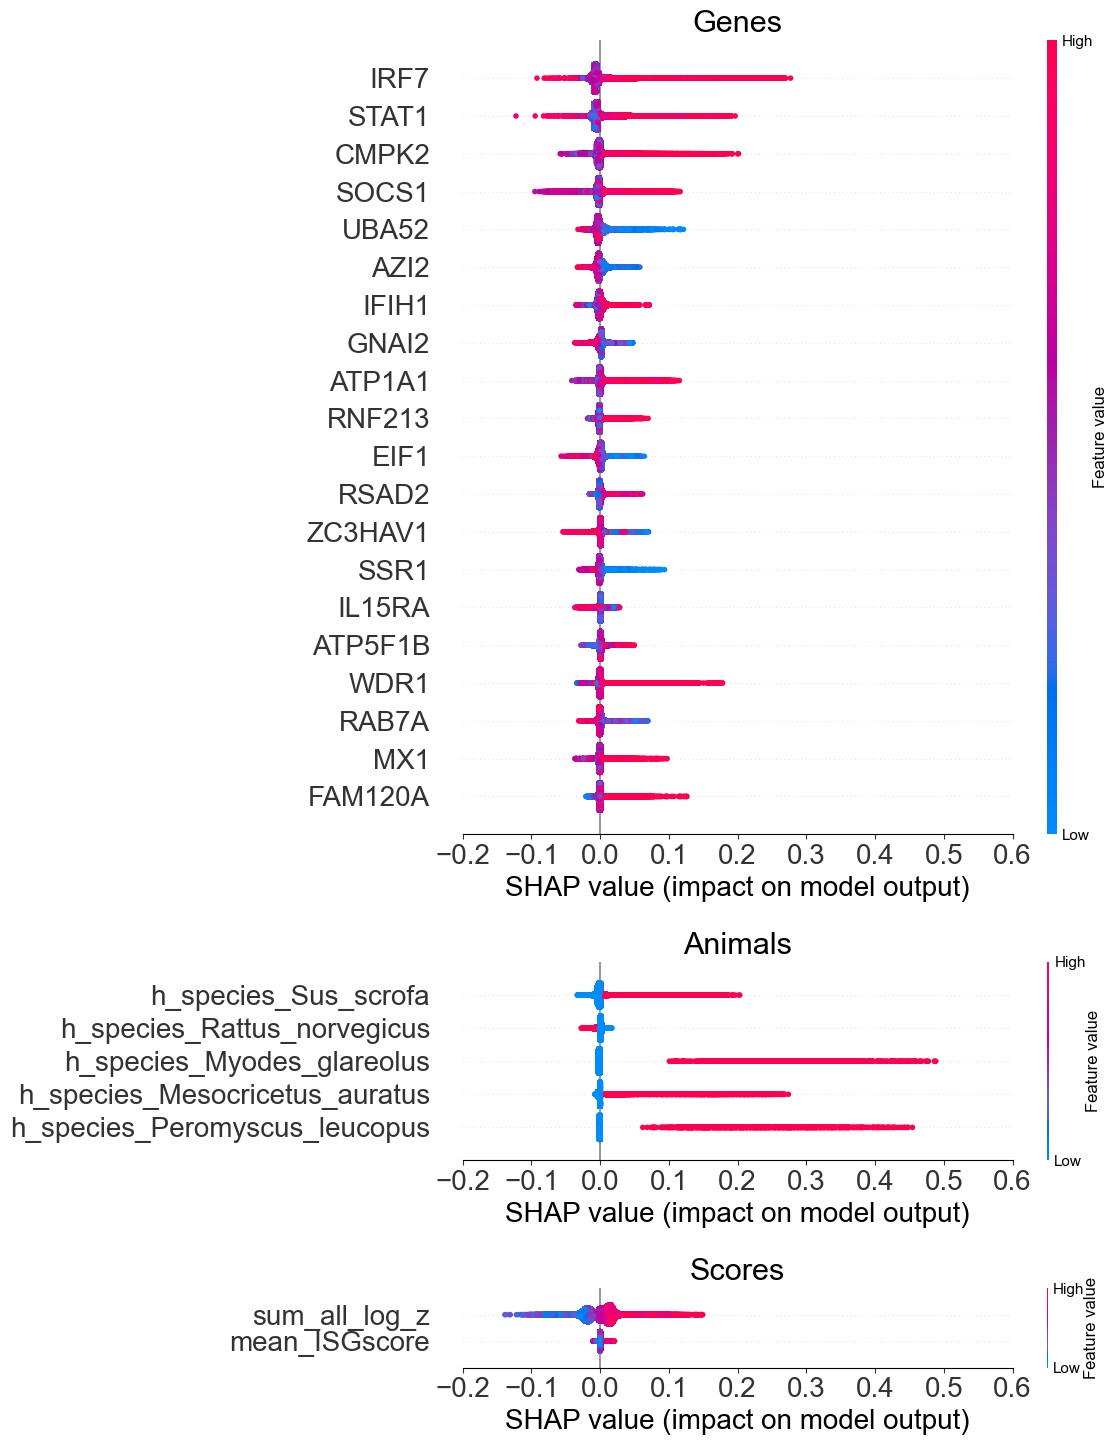

In [22]:
# Processes data for a single fold, trains a model, and computes SHAP values.
def process_data_and_get_shap(n, X, y, groups, folder_name, columns_to_process, exclude_columns):
    X_train_val, X_test, y_train_val, y_test, groups_train_val = split_data(X, y, groups, n)
    
    final_model_lgb, y_test_pred_label_lgb, y_test_pred_prob_lgb, y_train_pred_prob_lgb, f1_scores_lgb, pr_auc_lgb, threshold_lgb, encoder_lgb, matrix_lgb = train_model(X_train_val, X_test, y_train_val, y_test, groups_train_val, ensemble_type="lgb", n=n)
    
    encoder = encoder_lgb
    X_train_val_encoded = encoder.transform(X_train_val[columns_to_process])
    X_train_val_encoded = pd.DataFrame(X_train_val_encoded, index=X_train_val.index, columns=encoder.get_feature_names_out(columns_to_process))
    X_train_val_numeric = X_train_val.drop(columns=exclude_columns)
    X_train_val_final = pd.concat([X_train_val_numeric, X_train_val_encoded], axis=1).dropna()
    
    importance = final_model_lgb.feature_importance(importance_type='gain')
    importance_df = pd.DataFrame({'Loop': n, 'Feature': X_train_val_final.columns, 'Importance': importance})
    
    explainer = shap.TreeExplainer(final_model_lgb)
    shap_values = explainer.shap_values(X_train_val_final)
    
    return importance_df, pd.DataFrame(shap_values, columns=X_train_val_final.columns), X_train_val_final

# Aligns columns of dataframes and SHAP value arrays, then combines them.
def align_and_combine_data(dfs, shap_values_list, required_features):
    all_dfs, all_shap_values = [], []

    if not required_features:
        required_features = dfs[0].columns.tolist()

    for df, shap_df in zip(dfs, shap_values_list):
        shap_vals = shap_df.values
        
        df_aligned = df.reindex(columns=required_features)

        col_to_idx = {col: i for i, col in enumerate(df.columns)}
        reorder_idx = [col_to_idx.get(col, -1) for col in df_aligned.columns]

        shap_vals_aligned = np.full((shap_vals.shape[0], len(required_features)), np.nan)
        
        for i, original_idx in enumerate(reorder_idx):
            if original_idx != -1:
                shap_vals_aligned[:, i] = shap_vals[:, original_idx]

        all_dfs.append(df_aligned)
        all_shap_values.append(shap_vals_aligned)

    return pd.concat(all_dfs, ignore_index=True), np.vstack(all_shap_values)

# Creates and saves a combined SHAP summary plot, grouped by feature type.
def create_combined_shap_plot(df_all, shap_values_all, folder_name):
    gene_cols = [c for c in df_all.columns if not (c.startswith("h_species") or c.startswith("order") or c.startswith("sum_all_log_z") or c.startswith("mean_ISGscore"))]
    animal_mask = df_all.columns.str.startswith("h_species")
    score_mask = df_all.columns.str.startswith("sum_all_log_z") | df_all.columns.str.startswith("mean_ISGscore")
    
    all_shap_for_scale = np.concatenate([
        np.nan_to_num(shap_values_all[:, animal_mask], nan=0.0),
        np.nan_to_num(shap_values_all[:, [df_all.columns.get_loc(c) for c in gene_cols]], nan=0.0),
        np.nan_to_num(shap_values_all[:, score_mask], nan=0.0)
    ], axis=1)
    shap_min, shap_max = np.min(all_shap_for_scale), np.max(all_shap_for_scale)
    xticks = np.arange(np.floor(shap_min * 10) / 10, np.ceil(shap_max * 10) / 10 + 0.1, 0.1)

    heights = [20, 5, 2]
    bar_height = 0.55
    fig, axes = plt.subplots(3, 1, figsize=(12, sum(heights) * bar_height), gridspec_kw={'height_ratios': heights}, sharex=True)
    
    plt.sca(axes[0])
    shap.summary_plot(np.nan_to_num(shap_values_all[:, [df_all.columns.get_loc(c) for c in gene_cols]], nan=0.0), df_all[gene_cols].fillna(0), show=False, max_display=20, plot_size=None)
    axes[0].set_xlim(shap_min, shap_max)
    axes[0].set_title("Genes", fontsize=22)
    
    plt.sca(axes[1])
    shap.summary_plot(np.nan_to_num(shap_values_all[:, animal_mask], nan=0.0), df_all.loc[:, animal_mask].fillna(0), show=False, max_display=5, plot_size=None)
    axes[1].set_xlim(shap_min, shap_max)
    axes[1].set_title("Animals", fontsize=22)

    plt.sca(axes[2])
    shap.summary_plot(np.nan_to_num(shap_values_all[:, score_mask], nan=0.0), df_all.loc[:, score_mask].fillna(0), show=False, max_display=5, plot_size=None)
    axes[2].set_xlim(shap_min, shap_max)
    axes[2].set_title("Scores", fontsize=22)
    
    for ax in axes:
        ax.set_xticks(xticks)
        ax.tick_params(labelsize=20)
        ax.xaxis.label.set_size(20)
        ax.yaxis.label.set_size(20)
    
    plt.tight_layout()
    fig.savefig(f"./{folder_name}/shap_summary_all.pdf", bbox_inches='tight')
    plt.show()
    plt.close()

columns_to_process = ["h_species", "order"]
exclude_columns = ["ID", "h_species", "order"]
if __name__ == '__main__':
    # Main execution: runs the process for all folds and generates the final SHAP plot.
    results = []
    shap_dfs = []
    train_dfs = []
    
    for n in range(5):
        importance_df, shap_df, train_df = process_data_and_get_shap(n, X, y, groups, folder_name, columns_to_process, exclude_columns)
        results.append(importance_df)
        shap_dfs.append(shap_df)
        train_dfs.append(train_df)
    
    importances_df = pd.concat(results, ignore_index=True)
    importances_df.to_csv(f"./{folder_name}/importance_df.csv", index=False)
    
    with open(f"./{folder_name}/shap_dfs.pkl", "wb") as f:
        pickle.dump(shap_dfs, f)
    
    try:
        required_features
    except NameError:
        required_features = train_dfs[0].columns.tolist()

    df_all, shap_values_all = align_and_combine_data(train_dfs, shap_dfs, required_features)

    create_combined_shap_plot(df_all, shap_values_all, folder_name)

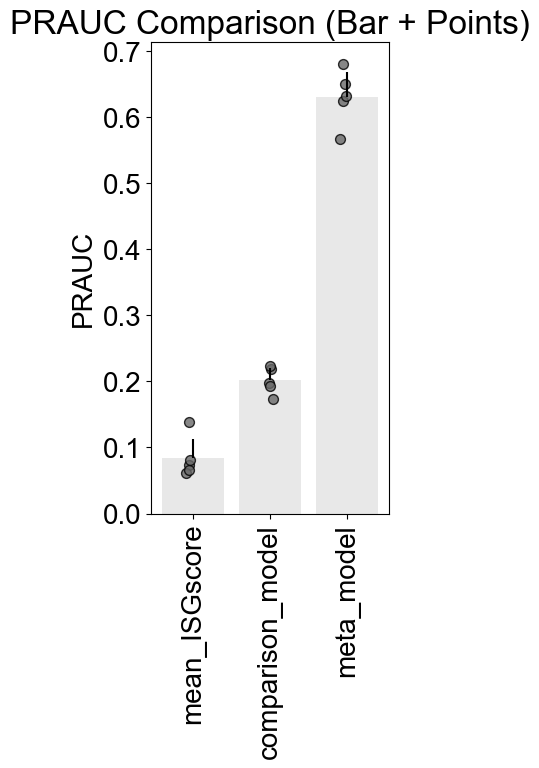

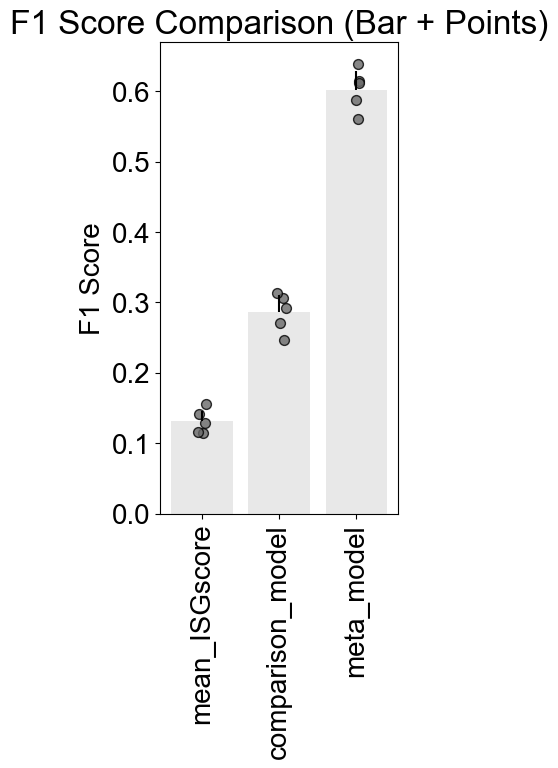

In [25]:
def plot_model_bar_with_points(data_dict, score_name, folder_name):

    models = list(data_dict.keys())
    plt.figure(figsize=(4, 6))

    # means and stds
    means = [np.mean(data_dict[m]) for m in models]
    stds = [np.std(data_dict[m]) for m in models]
    bar_positions = np.arange(len(models))
    
    # Plot bars with standard deviation as upper error bars
    plt.bar(
        bar_positions,
        means,
        yerr=[np.zeros_like(stds), stds],
        color="lightgray",
        alpha=0.5,
        capsize=0
    )

    # Plot individual data points with a slight horizontal jitter
    for i, model in enumerate(models):
        y = data_dict[model]
        x = np.random.normal(i, 0.04, size=len(y))
        plt.scatter(x, y, color="dimgray", s=50, edgecolor="k", alpha=0.8)

    plt.xticks(bar_positions, models)
    plt.ylabel(score_name)
    plt.title(f"{score_name} Comparison (Bar + Points)")
    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.savefig(f"./{folder_name}/Modelcomparison_{score_name}_barplot_points.pdf", bbox_inches='tight')
    plt.show()


# PRAUC
data_prauc_dict = {
    "mean_ISGscore": mean_prauc,
    "comparison_model": comp_prauc,
    "meta_model": prauc_meta
}
plot_model_bar_with_points(data_prauc_dict, "PRAUC", folder_name)

# F1 Score
data_f1_dict = {
    "mean_ISGscore": mean_f1score,
    "comparison_model": comp_f1score,
    "meta_model": f1score_meta
}
plot_model_bar_with_points(data_f1_dict, "F1 Score", folder_name)


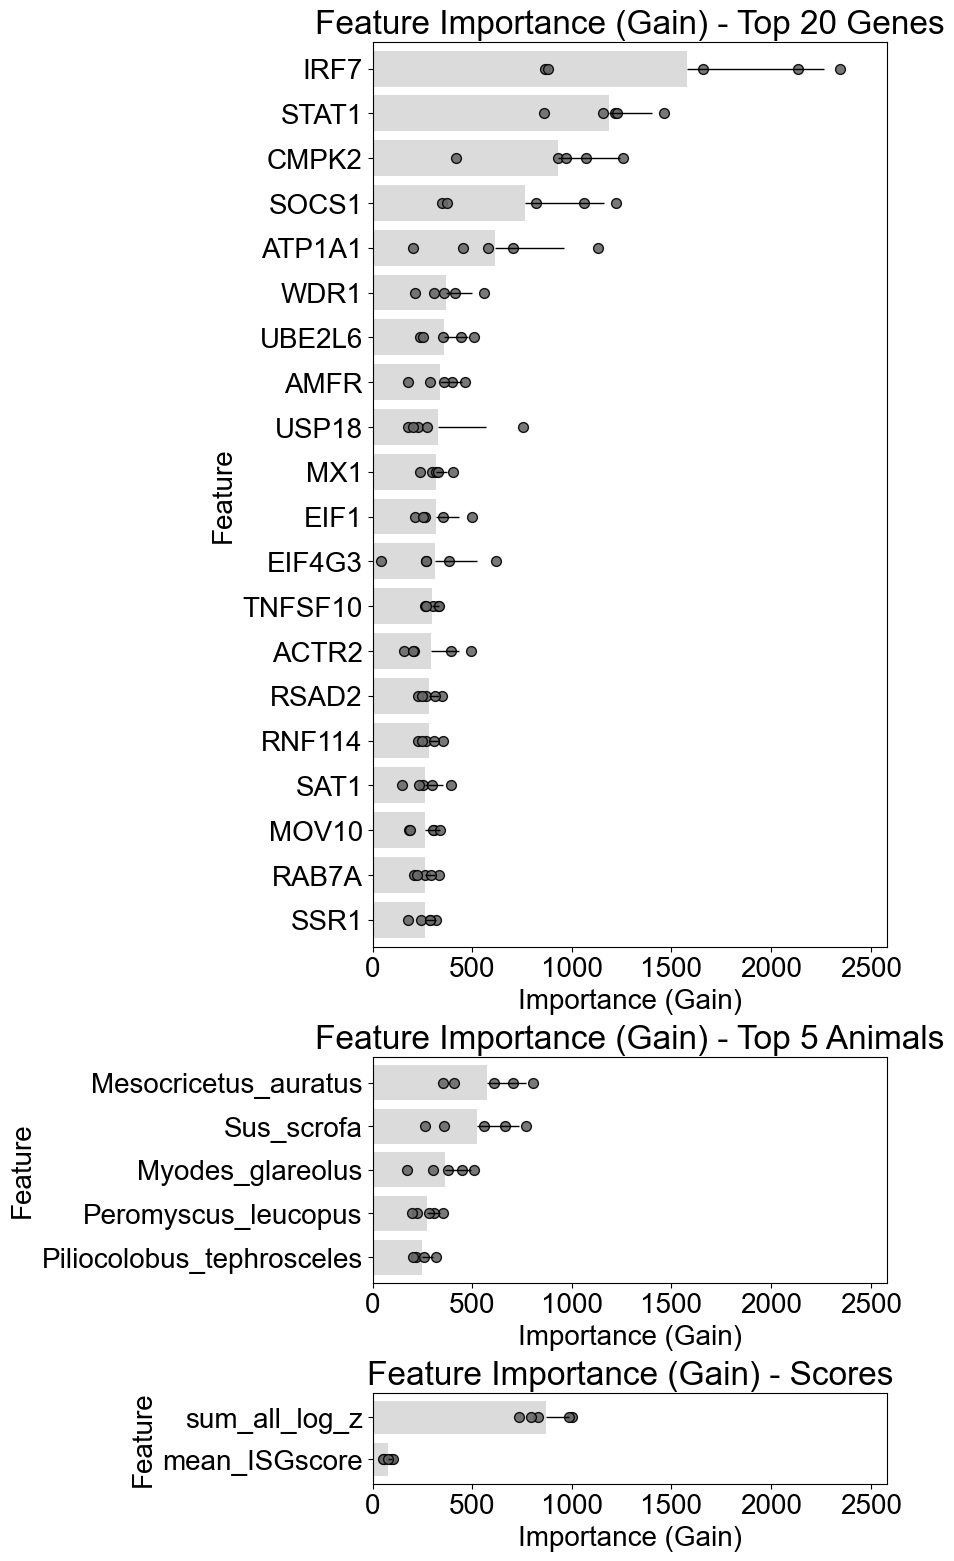

In [26]:
# Select top features for different categories based on mean importance.
animal_features = importances_df[importances_df["Feature"].str.startswith("h_species")] \
                  .groupby("Feature")["Importance"].mean() \
                  .sort_values(ascending=False).head(5).index
animal_features_order = importances_df[importances_df["Feature"].str.startswith("order")] \
                  .groupby("Feature")["Importance"].mean() \
                  .sort_values(ascending=False).head(5).index

other_features = ["mean_ISGscore", "sum_all_log_z"]

exclude_features = list(animal_features) + other_features + list(animal_features_order)
gene_features = importances_df[~importances_df["Feature"].isin(exclude_features)] \
                .groupby("Feature")["Importance"].mean() \
                .sort_values(ascending=False).head(20).index

# Set up categories and plot dimensions for visualization.
categories = {
    "Top 20 Genes": gene_features,
    "Top 5 Animals": animal_features,
    "Scores": other_features
}

all_importances = importances_df[importances_df["Feature"].isin(
    list(gene_features) + list(animal_features) + other_features + list(animal_features_order)
)]["Importance"]
x_min, x_max = 0, all_importances.max() * 1.1

bar_height = 0.5
heights = [len(features) * bar_height for features in categories.values()]

# Create a figure with subplots for each feature category.
fig, axes = plt.subplots(
    nrows=len(categories),
    ncols=1,
    figsize=(9, sum(heights) + 2),
    gridspec_kw={'height_ratios': heights},
    constrained_layout=True
)

# Generate a plot for each category, showing mean importance, standard deviation, and fold-specific values.
if len(categories) == 1:
    axes = [axes] # Ensure axes is iterable even with one subplot

for ax, (cat_name, features) in zip(axes, categories.items()):
    top_importances_cat = importances_df[importances_df["Feature"].isin(features)].copy()
    
    top_importances_cat["Feature_display"] = top_importances_cat["Feature"].str.replace("^h_species_", "", regex=True)
    
    mean_importance_order = top_importances_cat.groupby("Feature_display")["Importance"].mean().sort_values(ascending=False).index
    top_importances_cat["Feature_display"] = pd.Categorical(top_importances_cat["Feature_display"], categories=mean_importance_order, ordered=True)
    
    mean_vals = top_importances_cat.groupby("Feature_display")["Importance"].mean().sort_values(ascending=True)
    ax.barh(mean_vals.index, mean_vals.values, color="lightgray", alpha=0.8)
    
    std_vals = top_importances_cat.groupby("Feature_display")["Importance"].std().reindex(mean_vals.index)
    
    y_pos = np.arange(len(mean_vals))
    ax.errorbar(
        x=mean_vals.values,
        y=y_pos,
        xerr=[np.zeros(len(std_vals)), std_vals.values],
        fmt="none",
        ecolor="black",
        capsize=0,
        linewidth=1
    )
    
    for fold_num in sorted(top_importances_cat["Loop"].unique()):
        fold_data = top_importances_cat[top_importances_cat["Loop"] == fold_num]
        ax.scatter(
            fold_data["Importance"],
            fold_data["Feature_display"],
            color="dimgray",
            s=50,
            edgecolor='k',
            alpha=0.9
        )
    
    ax.set_title(f"Feature Importance (Gain) - {cat_name}")
    ax.set_xlabel("Importance (Gain)")
    ax.set_ylabel("Feature")
    ax.set_xlim(x_min, x_max)
    ax.margins(y=0.2/len(features))

# Save the figure to a file and display it.
plt.savefig(f"./{folder_name}/feature_importance_all.pdf", bbox_inches='tight')
plt.show()

In [28]:
combined_df = pd.concat([df.assign(Loop=i) for i, df in enumerate(all_merged_dfs)], ignore_index=True)
combined_df.to_csv(f"./{folder_name}/Prediction_Result.txt", sep="\t", index=False)

importances_df.to_csv(f"./{folder_name}/Feature_importances.txt", sep="\t", index=False)

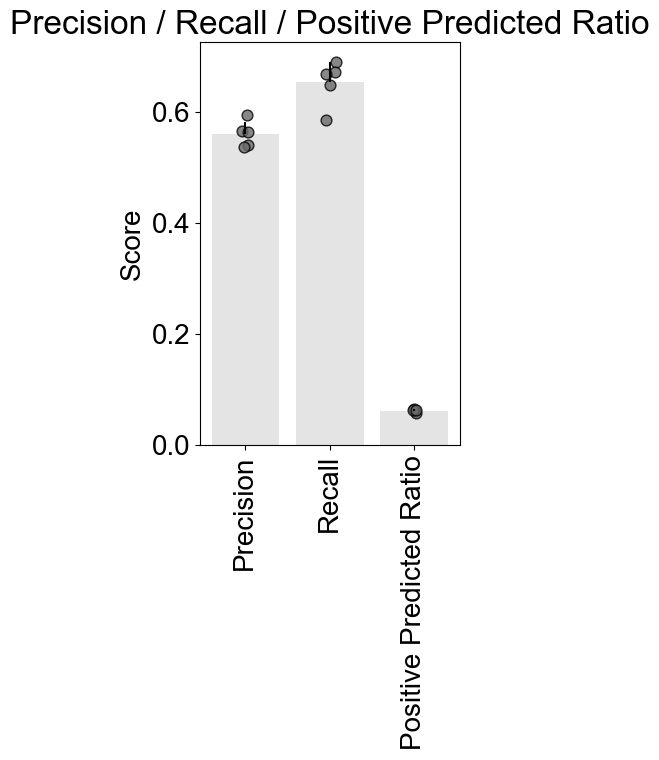

In [29]:
positive_rates = []
recalls = []
precisions = []
# Calculate Precision and Recall, Positive ratio
for n in range(5):
    df = pd.read_csv(f"./{folder_name}/Infection_Prediction_Stacking_{n}.csv")
    
    pos_rate = (df["Prediction_Label"] == "Positive").mean()
    positive_rates.append(pos_rate)

    TP = ((df["Infection"] == "Positive") & 
          (df["Prediction_Label"] == "Positive")).sum()
    FN = ((df["Infection"] == "Positive") & 
          (df["Prediction_Label"] == "Negative")).sum()
    FP = ((df["Infection"] == "Negative") & 
          (df["Prediction_Label"] == "Positive")).sum()

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    recalls.append(recall)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    precisions.append(precision)

metrics = ["Precision", "Recall", "Positive Predicted Ratio"]
data_dict = {
    "Precision": precisions,
    "Recall": recalls,
    "Positive Predicted Ratio": positive_rates
}

# mean and stds
means = [np.mean(data_dict[m]) for m in metrics]
stds  = [np.std(data_dict[m]) for m in metrics]

bar_positions = np.arange(len(metrics))

# plot
plt.figure(figsize=(4, 8))

plt.bar(
    bar_positions,
    means,
    yerr=[np.zeros_like(stds), stds],
    color="lightgray",
    alpha=0.6,
    capsize=0
)

for i, metric in enumerate(metrics):
    y = data_dict[metric]
    x = np.random.normal(i, 0.04, size=len(y))
    plt.scatter(x, y, color="dimgray", s=60, edgecolor="black", alpha=0.8)

plt.xticks(bar_positions, metrics, rotation=90)
plt.ylabel("Score")
plt.title("Precision / Recall / Positive Predicted Ratio")
plt.tight_layout()
plt.savefig(f"./{folder_name}/Precision_Recall_PositivePredRatio_of_5Model.pdf", bbox_inches='tight')
plt.show()


In [30]:
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix

# get species list
all_species = set()

for n in range(5):
    df = pd.read_csv(f"./{folder_name}/Infection_Prediction_Stacking_{n}.csv")
    all_species.update(df['h_species'].unique())

all_species = list(all_species)
print("number of target species", len(all_species))
print(all_species)

# record f1 and cm
records = []

for n in range(5):
    df = pd.read_csv(f"./{folder_name}/Infection_Prediction_Stacking_{n}.csv")

    for sp in all_species:
        df_filtered = df[df['h_species'] == sp]
        if df_filtered.empty:
            continue

        y_true = df_filtered['Infection'].map({'Negative': 0, 'Positive': 1})
        y_pred = df_filtered['Prediction_Label'].map({'Negative': 0, 'Positive': 1})

        if len(set(y_true)) < 2:
            print(f"Skipped {sp} (only one class in y_true at fold {n})")
            continue

        f1 = f1_score(y_true, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        records.append((sp, n, f1, tp, fp, tn, fn))

f1_df = pd.DataFrame(
    records,
    columns=[
        'Species',
        'Fold',
        'F1',
        'TP',
        'FP',
        'TN',
        'FN'
    ]
)

f1_df.to_csv(f"./{folder_name}/F1score_by_species_with_CM.txt", sep="\t", index=False)

print("Saved:", f"./{folder_name}/F1score_by_species_with_CM.txt")


number of target species 1010
['Rattus_rattus', 'Dasypus_novemcinctus', 'Microtus_ochrogaster', 'Nyctidromus_albicollis', 'Buteo_japonicus', 'Bison_bison', 'Balaeniceps_rex', 'Sus_scrofa_domesticus', 'Capra_hircus', 'Scopus_umbretta', 'Sula_nebouxii', 'Erethizon_dorsatum', 'Rattus_norvegicus_albus', 'Otus_sunia', 'Peucedramus_taeniatus', 'Tadarida_brasiliensis', 'Aerodramus_maximus', 'Miniopterus_africanus', 'Microtus_oregoni', 'Pogoniulus_atroflavus', 'Anthochaera_phrygia', 'Zonotrichia_leucophrys', 'Alticola_macrotis', 'Mus_spicilegus', 'Platyspiza_crassirostris', 'Certhia_brachydactyla', 'Carollia_castanea', 'Acanthornis_magna_greeniana', 'Rostratula_benghalensis', 'Florisuga_fusca', 'Scotophilus_kuhlii', 'Erophylla_bombifrons', 'Antechinus_flavipes', 'Aquila_chrysaetos', 'Phaethon_lepturus', 'Lynx_pardinus', 'Plocepasser_mahali', 'Circus_maillardi', 'Alectoris_magna', 'Spinus_spinus', 'Neochmia_temporalis', 'Aythya_fuligula', 'Isoodon_obesulus', 'Varecia_variegata', 'Chionomys_niva

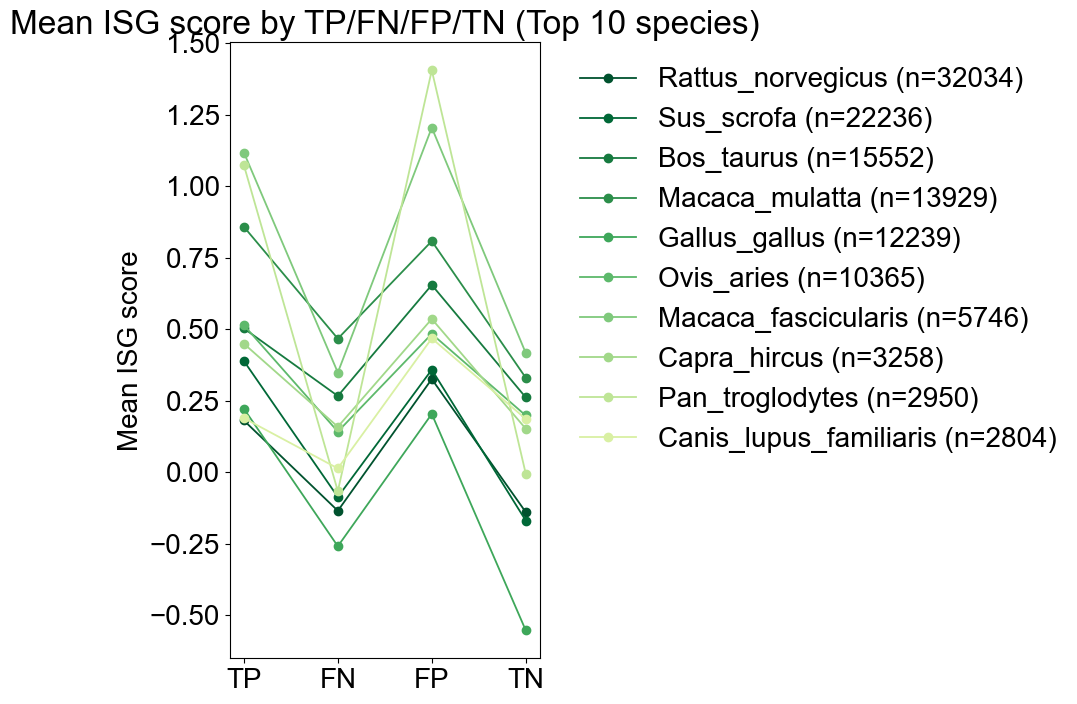

In [31]:
# assign label
def assign_confusion(row):
    if row["Infection"] == "Positive" and row["Prediction_Label"] == "Positive":
        return "TP"
    elif row["Infection"] == "Positive" and row["Prediction_Label"] == "Negative":
        return "FN"
    elif row["Infection"] == "Negative" and row["Prediction_Label"] == "Positive":
        return "FP"
    else:
        return "TN"


merged_all = merged_all.copy()
merged_all["confusion"] = merged_all.apply(assign_confusion, axis=1)

df_mean = (
    merged_all
    .groupby(["h_species", "confusion"])["mean_ISGscore"]
    .mean()
    .unstack()
)

df_counts = (
    merged_all
    .groupby("h_species")
    .size()
    .rename("n_samples")
)

n_top = 10

df_plot = (
    df_mean
    .join(df_counts)
    .dropna(subset=["TP", "FN", "FP", "TN"])
    .sort_values("n_samples", ascending=False)
    .head(n_top)
)

cmap = cm.get_cmap("YlGn")
color_vals = np.linspace(0.25, 0.95, len(df_plot))[::-1]

species_colors = {
    species: cmap(val)
    for species, val in zip(df_plot.index, color_vals)
}


# plot
plt.figure(figsize=(4, 8))

x_labels = ["TP", "FN", "FP", "TN"]
x_positions = np.arange(len(x_labels))

for species, row in df_plot.iterrows():
    ys = [row[label] for label in x_labels]

    plt.plot(
        x_positions,
        ys,
        marker="o",
        linewidth=1.3,
        markersize=6,
        color=species_colors[species],
        label=f"{species} (n={int(row['n_samples'])})"
    )

plt.xticks(x_positions, x_labels)
plt.ylabel("Mean ISG score")
plt.title(f"Mean ISG score by TP/FN/FP/TN (Top {n_top} species)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.savefig(
    f"./{folder_name}/Mean_ISGscore_by_TP_FN_FP_TN_Top{n_top}_species.pdf",
    bbox_inches="tight"
)
plt.show()


In [32]:
merge_info = merged_all[["ID", "mean_ISGscore", "Infection", "Prediction_Label"]]
merge_info

,ID,mean_ISGscore,Infection,Prediction_Label
0,DRR001894,0.399979,Negative,Negative
1,DRR001895,0.369820,Negative,Negative
2,DRR018832,0.095928,Negative,Positive
3,DRR018833,0.207653,Negative,Positive
4,DRR018834,0.099523,Negative,Positive
...,...,...,...,...
159543,SRR9986110,0.301730,Negative,Negative
159544,SRR9986111,0.348592,Negative,Negative
159545,SRR9986112,0.150200,Negative,Negative
159546,SRR9986114,-0.076673,Negative,Negative


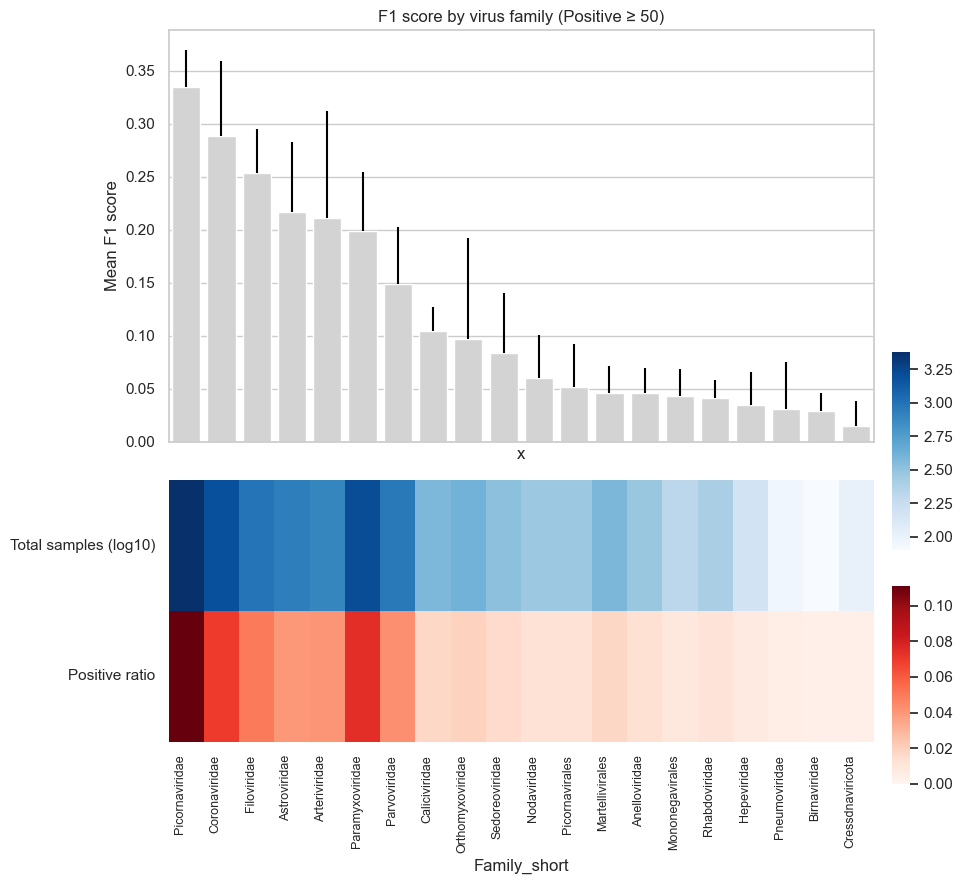

In [56]:
# parameters
k = 50
n_folds = 5

# load information
virus_info = pd.read_csv(
    "Aves_Mam_mbio_genomad_filt_ML_250630.txt",
    sep="\t"
)
virus_meta = pd.read_csv(
    "ISG_virus_family_251111.txt",
    sep="\t"
)
isg_high_families = set(
    virus_meta.loc[
        virus_meta["ISG_level"] == "high",
        "taxonomy"
    ]
)

# load prediction data
dfs = []
for n in range(n_folds):
    path = f"./{folder_name}/Infection_Prediction_Stacking_{n}.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["Fold"] = n
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

def make_short_name(tax):
    parts = tax.split(";")
    for p in reversed(parts):
        if p.strip():
            return p.strip()
    return tax

# count positive
positive_df = (
    df_all[df_all["Infection"] == "Positive"]
    .merge(
        virus_info[["ID", "taxonomy"]],
        on="ID",
        how="left"
    )
)

pos_counts = (
    positive_df
    .groupby("taxonomy")
    .size()
    .reset_index(name="Positive_Count")
)

valid_families = (
    pos_counts[
        (pos_counts["Positive_Count"] >= k) &
        (pos_counts["taxonomy"].isin(isg_high_families))
    ]
)

# Calculate F1Score per fold and family
records = []

for n in range(n_folds):
    df_fold = df_all[df_all["Fold"] == n]
    df_global_neg = df_fold[df_fold["Infection"] == "Negative"]

    for family in valid_families["taxonomy"]:
        family_ids = virus_info.loc[
            virus_info["taxonomy"] == family,
            "ID"
        ]

        df_family_pos = df_fold[
            (df_fold["ID"].isin(family_ids)) &
            (df_fold["Infection"] == "Positive")
        ]

        if len(df_family_pos) == 0:
            continue

        df_eval = pd.concat([df_family_pos, df_global_neg])

        y_true = df_eval["Infection"].map({"Negative": 0, "Positive": 1})
        y_pred = df_eval["Prediction_Label"].map({"Negative": 0, "Positive": 1})

        f1 = f1_score(y_true, y_pred, zero_division=0)
        records.append((family, f1))

f1_df = pd.DataFrame(records, columns=["Family", "F1"])

summary_df = (
    f1_df
    .groupby("Family")
    .agg(
        F1_mean=("F1", "mean"),
        F1_std=("F1", "std")
    )
    .reset_index()
)

summary_df = summary_df.merge(
    valid_families,
    left_on="Family",
    right_on="taxonomy",
    how="left"
)

summary_df = summary_df.sort_values(
    "F1_mean", ascending=False
).reset_index(drop=True)

summary_df["Family_short"] = summary_df["Family"].apply(make_short_name)


# Sample counts for heatmap
count_df = (
    virus_info[virus_info["taxonomy"].isin(summary_df["Family"])]
    .merge(df_all[["ID", "Infection"]], on="ID", how="left")
    .groupby("taxonomy")
    .agg(
        Total_samples=("ID", "size"),
        Positive_samples=("Infection", lambda x: (x == "Positive").sum())
    )
    .reindex(summary_df["Family"])
)

total_all_samples = virus_info["ID"].nunique()

count_df["Positive_ratio"] = (
    count_df["Positive_samples"] / total_all_samples
)

total_counts = count_df["Total_samples"].values
total_counts_log = np.log10(1 + total_counts)
positive_ratio = count_df["Positive_ratio"].values

# plot
sns.set(style="whitegrid")

fig = plt.figure(
    figsize=(max(9, len(summary_df) * 0.4), 9)
)

ax_bar = plt.subplot2grid((5, 1), (0, 0), rowspan=3)

plot_df = summary_df.copy()
plot_df["x"] = np.arange(len(plot_df))

sns.barplot(
    data=plot_df,
    x="x",
    y="F1_mean",
    color="lightgray",
    ax=ax_bar
)

upper_err = plot_df["F1_std"].values
lower_err = np.zeros_like(upper_err)

ax_bar.errorbar(
    plot_df["x"],
    plot_df["F1_mean"],
    yerr=[lower_err, upper_err],
    fmt="none",
    ecolor="black",
    capsize=0
)

ax_bar.set_ylabel("Mean F1 score")
ax_bar.set_title(f"F1 score by virus family (Positive ≥ {k})")
ax_bar.set_xticks([])
ax_bar.set_xlim(-0.5, len(plot_df) - 0.5)

ax_hm = plt.subplot2grid((5, 1), (3, 0), rowspan=2)

hm_df = pd.DataFrame(
    {
        "Total samples (log10)": total_counts_log,
        "Positive ratio": positive_ratio
    },
    index=summary_df["Family_short"]
).T

mask_total = np.zeros_like(hm_df, dtype=bool)
mask_total[1, :] = True

mask_pos = np.zeros_like(hm_df, dtype=bool)
mask_pos[0, :] = True

sns.heatmap(
    hm_df,
    mask=mask_total,
    cmap="Blues",
    ax=ax_hm,
    cbar=True,
    cbar_ax=fig.add_axes([1.0, 0.38, 0.02, 0.22]),
    vmin=total_counts_log.min(),
    vmax=total_counts_log.max(),
    linewidths=0,
    xticklabels=True,
    yticklabels=True
)

sns.heatmap(
    hm_df,
    mask=mask_pos,
    cmap="Reds",
    ax=ax_hm,
    cbar=True,
    cbar_ax=fig.add_axes([1.0, 0.12, 0.02, 0.22]),
    vmin=0.0,
    vmax=np.nanmax(positive_ratio),
    linewidths=0,
    xticklabels=True,
    yticklabels=True
)

ax_hm.set_yticklabels(
    ax_hm.get_yticklabels(),
    rotation=0,
    va="center"
)

ax_hm.set_xticklabels(
    summary_df["Family_short"],
    rotation=90,
    ha="right",
    fontsize=9
)

ax_hm.set_ylabel("")

plt.tight_layout()
plt.savefig(
    f"./{folder_name}/F1Score_per_Virus(Positive>={k})_with_Heatmap.pdf",
    bbox_inches="tight"
)
plt.show()


In [57]:
meta = pd.read_csv(meta_file, sep="\t")
meta = meta.drop(columns=["Infection"])
meta

,ID,Host_species,BioProject_ID,species,tax_id,kingdom,phylum,class,order,family,genus,nucleotide_DNA,nucleotide_RNA,ISG_level
0,SRR7467387,Zonotrichia_albicollis,PRJNA478852,Zonotrichia_albicollis,44394,Eukaryota,Chordata,Aves,Passeriformes,Passerellidae,Zonotrichia,Negative,Negative,Negative
1,SRR7467388,Zonotrichia_albicollis,PRJNA478852,Zonotrichia_albicollis,44394,Eukaryota,Chordata,Aves,Passeriformes,Passerellidae,Zonotrichia,Negative,Negative,Negative
2,SRR7467389,Zonotrichia_albicollis,PRJNA478852,Zonotrichia_albicollis,44394,Eukaryota,Chordata,Aves,Passeriformes,Passerellidae,Zonotrichia,Negative,Negative,Negative
3,SRR7467390,Zonotrichia_albicollis,PRJNA478852,Zonotrichia_albicollis,44394,Eukaryota,Chordata,Aves,Passeriformes,Passerellidae,Zonotrichia,Negative,Positive,high
4,SRR7467391,Zonotrichia_albicollis,PRJNA478852,Zonotrichia_albicollis,44394,Eukaryota,Chordata,Aves,Passeriformes,Passerellidae,Zonotrichia,Negative,Negative,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177072,ERR168845,Ficedula_hypoleuca,PRJEB2984,Ficedula_hypoleuca,46689,Eukaryota,Chordata,Aves,Passeriformes,Muscicapidae,Ficedula,Negative,Negative,Negative
177073,ERR168846,Ficedula_albicollis,PRJEB2984,Ficedula_albicollis,59894,Eukaryota,Chordata,Aves,Passeriformes,Muscicapidae,Ficedula,Negative,Negative,Negative
177074,ERR168847,Ficedula_hypoleuca,PRJEB2984,Ficedula_hypoleuca,46689,Eukaryota,Chordata,Aves,Passeriformes,Muscicapidae,Ficedula,Negative,Negative,Negative
177075,ERR168848,Ficedula_albicollis,PRJEB2984,Ficedula_albicollis,59894,Eukaryota,Chordata,Aves,Passeriformes,Muscicapidae,Ficedula,Negative,Negative,Negative


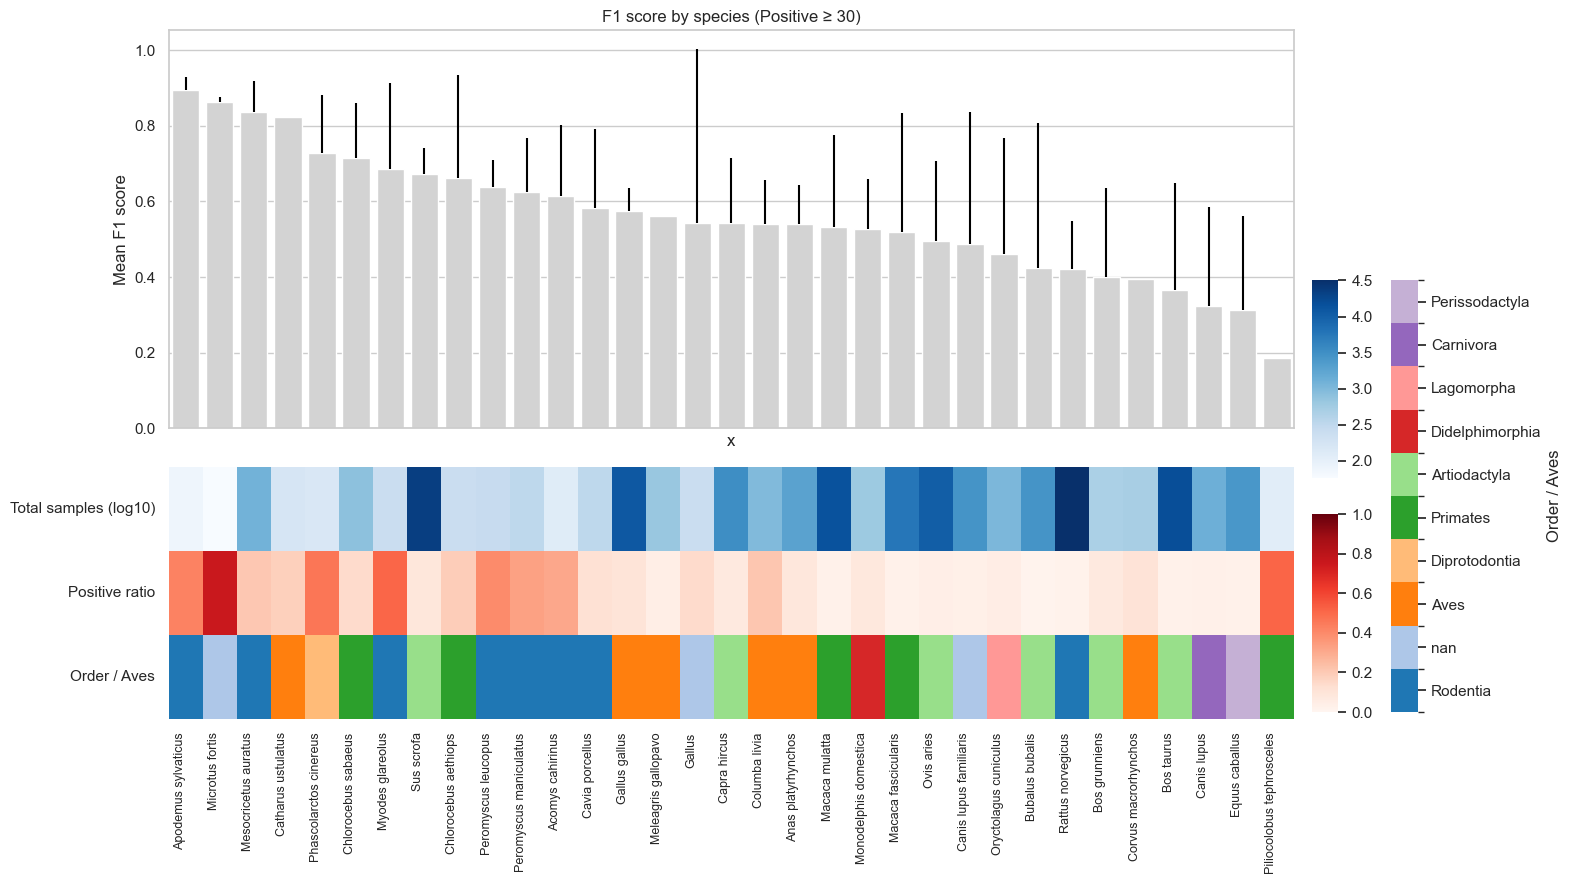

In [58]:
# Parameters
k = 30
n_folds = 5

# Load prediction results
dfs = []
for n in range(n_folds):
    path = f"./{folder_name}/Infection_Prediction_Stacking_{n}.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["Fold"] = n
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Load metadata
meta_df = pd.read_csv(meta_file, sep="\t")
meta_df = meta_df.rename(columns={"species": "h_species"})
meta_df = meta_df.loc[:, ["h_species", "order", "class"]]
meta_df = meta_df.drop_duplicates(subset=["h_species"])

meta_df["Order_display"] = np.where(
    meta_df["class"] == "Aves",
    "Aves",
    meta_df["order"]
)

# Count Positive samples
pos_counts = (
    df_all[df_all["Infection"] == "Positive"]
    .groupby("h_species")
    .size()
    .reset_index(name="Positive_Count")
)

valid_species = pos_counts[pos_counts["Positive_Count"] >= k]

# Compute F1
records = []

for sp in valid_species["h_species"]:
    for fold in sorted(df_all["Fold"].unique()):
        df_sp = df_all[(df_all["Fold"] == fold) & (df_all["h_species"] == sp)]
        if df_sp["Infection"].nunique() < 2:
            continue
        y_true = df_sp["Infection"].map({"Negative": 0, "Positive": 1})
        y_pred = df_sp["Prediction_Label"].map({"Negative": 0, "Positive": 1})
        records.append((sp, fold, f1_score(y_true, y_pred)))

f1_df = pd.DataFrame(records, columns=["Species", "Fold", "F1"])

summary_df = (
    f1_df.groupby("Species")
    .agg(F1_mean=("F1", "mean"), F1_std=("F1", "std"))
    .reset_index()
)

summary_df = (
    summary_df
    .merge(valid_species.rename(columns={"h_species": "Species"}), on="Species")
    .sort_values("F1_mean", ascending=False)
    .reset_index(drop=True)
)

# Heatmap data
count_df = (
    df_all[df_all["h_species"].isin(summary_df["Species"])]
    .groupby("h_species")
    .agg(
        Total_samples=("Infection", "size"),
        Positive_samples=("Infection", lambda x: (x == "Positive").sum())
    )
    .reindex(summary_df["Species"])
)

count_df["Positive_ratio"] = (
    count_df["Positive_samples"] / count_df["Total_samples"]
)

order_df = (
    meta_df.set_index("h_species")
    .reindex(summary_df["Species"])
)

order_labels = order_df["Order_display"].values
unique_orders = pd.unique(order_labels)
order_to_id = {o: i for i, o in enumerate(unique_orders)}
order_ids = np.array([order_to_id[o] for o in order_labels])

# Plot
sns.set(style="whitegrid")

fig = plt.figure(figsize=(max(9, len(summary_df) * 0.4), 9))

ax_bar = plt.subplot2grid((5, 1), (0, 0), rowspan=3)

plot_df = summary_df.copy()
plot_df["x"] = np.arange(len(plot_df))

sns.barplot(
    data=plot_df,
    x="x",
    y="F1_mean",
    color="lightgray",
    ax=ax_bar
)

ax_bar.errorbar(
    plot_df["x"],
    plot_df["F1_mean"],
    yerr=[np.zeros(len(plot_df)), plot_df["F1_std"]],
    fmt="none",
    ecolor="black"
)

ax_bar.set_ylabel("Mean F1 score")
ax_bar.set_title(f"F1 score by species (Positive ≥ {k})")
ax_bar.set_xticks([])
ax_bar.set_xlim(-0.5, len(plot_df) - 0.5)

ax_hm = plt.subplot2grid((5, 1), (3, 0), rowspan=2)

hm_df = pd.DataFrame(
    {
        "Order": order_ids,
        "Positive ratio": count_df["Positive_ratio"].values,
        "Total samples (log10)": np.log10(1 + count_df["Total_samples"].values)
    },
    index=summary_df["Species"]
).T.iloc[::-1]

mask_total = np.zeros_like(hm_df, dtype=bool)
mask_total[1:, :] = True

mask_pos = np.zeros_like(hm_df, dtype=bool)
mask_pos[[0, 2], :] = True

mask_order = np.zeros_like(hm_df, dtype=bool)
mask_order[:2, :] = True

sns.heatmap(
    hm_df,
    mask=mask_total,
    cmap="Blues",
    ax=ax_hm,
    cbar=True,
    cbar_ax=fig.add_axes([1.0, 0.46, 0.02, 0.22]),
    linewidths=0
)

sns.heatmap(
    hm_df,
    mask=mask_pos,
    cmap="Reds",
    ax=ax_hm,
    cbar=True,
    cbar_ax=fig.add_axes([1.0, 0.20, 0.02, 0.22]),
    vmin=0,
    vmax=1,
    linewidths=0
)

sns.heatmap(
    hm_df,
    mask=mask_order,
    cmap="tab20",
    ax=ax_hm,
    cbar=True,
    cbar_ax=fig.add_axes([1.06, 0.20, 0.02, 0.48]),
    norm=BoundaryNorm(
        np.arange(len(unique_orders) + 1) - 0.5,
        len(unique_orders)
    ),
    linewidths=0
)

cbar_order = ax_hm.collections[2].colorbar
cbar_order.set_ticks(np.arange(len(unique_orders)))
cbar_order.set_ticklabels(unique_orders)
cbar_order.set_label("Order / Aves", rotation=90)

ax_hm.set_yticklabels(
    ["Total samples (log10)", "Positive ratio", "Order / Aves"],
    rotation=0,
    va="center"
)

ax_hm.set_xticklabels(
    summary_df["Species"].str.replace("_", " "),
    rotation=90,
    ha="right",
    fontsize=9
)

ax_hm.set_xlabel("")
ax_hm.set_ylabel("")

plt.tight_layout()
plt.savefig(
    f"./{folder_name}/F1Score_per_Species(Positive>={k})_with_Order_Heatmap.pdf",
    bbox_inches="tight"
)
plt.show()
